# NorthStar - R Analytics, Visualisation and Regression

**Notebook 3 of the analytical workflow.** Builds on the cleaned data from `01_eda.ipynb` and complements the SQL work in `02_sql_in_r.ipynb`.

## Purpose
Where `02_sql_in_r` produced the league tables, this notebook does the **statistical work**: it tests whether the apparent patterns survive formal hypothesis tests, then fits regression models to quantify *how much* each operational factor contributes to delivery outcomes and customer ratings. The output is a set of evidence-grade findings that the final report can stand behind.

## Structure
1. **Setup** - packages and data load.
2. **Descriptive analytics with `dplyr`** - group-by summaries that go beyond what SQL did.
3. **Visualisation with `ggplot2`** - the four charts the report will reuse.
4. **Statistical tests**
   - Chi-square: is hub-level variation in failure real?
   - One-way ANOVA: is the severity -> resolution-time inversion statistically significant?
   - Welch t-test: do failed deliveries actually have more manual overrides?
5. **Linear regression** - `customer_rating_post_delivery ~ route + driver + hub` features.
6. **Logistic regression** - `failed ~ ...` to model the binary outcome and read off odds ratios.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Databases and Analytics 2')
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/Databases and Analytics 2
['northstar_dataset.zip', 'Databases and Analytics Assignment 2025-26 S2-with Partners.pdf', 'Case Study Databases and Analytics Module S2 2026 - NorthStar Urban Mobility and Logistics.pdf', 'Week 5-Data Analysis and Linear Regression Modeling.pptx', 'Week 4-2- SQL Queries in R using sqldf.pptx', 'Week 2 semester 2 with plenary slides 2026.pptx', 'Week 3 Semester 2 plenary slides 2026.pptx', 'Lecture 1- Introduction to Databases and Analytics.pptx', 'Untitled document.docx', '05_mongodb_design.ipynb', '06_indexing.ipynb', 'northstar_dataset', 'cleaned_data', '01_eda.ipynb', 'youtube_scrapfly_full.xlsx', 'analysis_output', '04_python_analysis.ipynb', '02_sql_in_r.ipynb', '03_r_analytics.ipynb']


In [ ]:
%load_ext rpy2.ipython

## 1. Setup

In [ ]:
%%R
required <- c("tidyverse", "broom", "scales", "lubridate")
new_pkgs <- required[!required %in% installed.packages()[, "Package"]]
if (length(new_pkgs)) install.packages(new_pkgs, repos = "https://cloud.r-project.org", quiet = TRUE)

suppressPackageStartupMessages({
  library(tidyverse)   # dplyr + ggplot2 + tidyr + readr together
  library(broom)       # tidy() / glance() / augment() for model output
  library(scales)
  library(lubridate)
})

theme_set(theme_minimal(base_size = 11))
options(repr.plot.width = 9, repr.plot.height = 5)  # Colab-friendly defaults

cat("R", R.version$major, ".", R.version$minor, " loaded.\n", sep = "")


R4.6.0 loaded.


In [ ]:
%%R
# Load the cleaned data produced by notebook 01
DATA_DIR <- "cleaned_data"
suppressMessages({
  hubs       <- read_csv(file.path(DATA_DIR, "hubs.csv"))
  customers  <- read_csv(file.path(DATA_DIR, "customers.csv"))
  drivers    <- read_csv(file.path(DATA_DIR, "drivers.csv"))
  vehicles   <- read_csv(file.path(DATA_DIR, "vehicles.csv"))
  orders     <- read_csv(file.path(DATA_DIR, "orders.csv"))
  deliveries <- read_csv(file.path(DATA_DIR, "deliveries.csv"))
  incidents  <- read_csv(file.path(DATA_DIR, "incidents.csv"))
  complaints <- read_csv(file.path(DATA_DIR, "complaints.csv"))
  app_events <- read_csv(file.path(DATA_DIR, "app_events.csv"))
})

# Master delivery table - same shape as the Python notebook 04 used
master <- deliveries %>%
  left_join(orders     %>% select(order_id, customer_id, service_type, promised_window_hours,
                                  pickup_zone, dropoff_zone, priority_level, order_value),
            by = "order_id") %>%
  left_join(drivers    %>% select(driver_id, base_zone, employment_type, years_experience,
                                  training_score, driver_rating),
            by = "driver_id") %>%
  left_join(vehicles   %>% select(vehicle_id, vehicle_type, battery_health_pct,
                                  maintenance_status),
            by = "vehicle_id") %>%
  left_join(hubs       %>% select(hub_id, hub_name, hub_zone = zone, hub_type, capacity_score),
            by = "hub_id") %>%
  mutate(
    duration_hr     = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours")),
    failed          = as.integer(delivery_status == "Failed"),
    delayed         = as.integer(delivery_status == "Delayed"),
    bad_outcome     = pmax(failed, delayed),
    hub_zone_match  = as.integer(hub_zone == pickup_zone),
    sla_breach      = as.integer(duration_hr > promised_window_hours)
  )

cat("master:", nrow(master), "x", ncol(master), "\n")
cat("Failed:", scales::percent(mean(master$failed), 0.1),
    " Delayed:", scales::percent(mean(master$delayed), 0.1),
    " Bad:", scales::percent(mean(master$bad_outcome), 0.1), "\n")


master: 950 x 38 
Failed: 13.9%  Delayed: 21.3%  Bad: 35.2% 


## 2. Descriptive analytics with `dplyr`

Group-by summaries are easier to read in `dplyr` than in SQL because the pipeline is left-to-right. I use them to set up the analytical questions for sections 3–6.

In [ ]:
%%R
# Hub league table - same shape as the SQL query in notebook 02, but expressed
# in dplyr so it's easy to chain further calculations.
hub_summary <- master %>%
  group_by(hub_name, hub_zone, hub_type, capacity_score) %>%
  summarise(
    n             = n(),
    fail_rate     = mean(failed),
    delay_rate    = mean(delayed),
    bad_rate      = mean(bad_outcome),
    avg_duration  = mean(duration_hr, na.rm = TRUE),
    avg_rating    = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_cost      = mean(fuel_or_charge_cost, na.rm = TRUE),
    .groups       = "drop"
  ) %>%
  arrange(desc(bad_rate))

hub_summary


# A tibble: 8 × 11
  hub_name  hub_zone hub_type capacity_score     n fail_rate delay_rate bad_rate
  <chr>     <chr>    <chr>             <dbl> <int>     <dbl>      <dbl>    <dbl>
1 Central … Central  Control              88   115    0.2         0.217    0.417
2 Airport … Airport  Dispatch             71   104    0.144       0.260    0.404
3 Midtown … Central  Charging             63   128    0.203       0.172    0.375
4 West Gate West     Dispatch             69   127    0.126       0.220    0.346
5 South Li… South    Dispatch             78   106    0.0943      0.245    0.340
6 Riversid… Riversi… Warehou…             66   115    0.122       0.217    0.339
7 North Ex… North    Dispatch             82   136    0.125       0.191    0.316
8 East Dock East     Warehou…             74   119    0.0924      0.193    0.286
# ℹ 3 more variables: avg_duration <dbl>, avg_rating <dbl>, avg_cost <dbl>


In [ ]:
%%R
# Service-type profitability with one-line CI on the margin
service_summary <- master %>%
  group_by(service_type) %>%
  summarise(
    n          = n(),
    avg_value  = mean(order_value, na.rm = TRUE),
    avg_cost   = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_margin = mean(order_value - fuel_or_charge_cost, na.rm = TRUE),
    sd_margin  = sd(order_value - fuel_or_charge_cost, na.rm = TRUE),
    fail_rate  = mean(failed),
    .groups    = "drop"
  ) %>%
  mutate(
    margin_ci_low  = avg_margin - 1.96 * sd_margin / sqrt(n),
    margin_ci_high = avg_margin + 1.96 * sd_margin / sqrt(n)
  )
service_summary %>% select(-sd_margin)


# A tibble: 5 × 8
  service_type     n avg_value avg_cost avg_margin fail_rate margin_ci_low
  <chr>        <int>     <dbl>    <dbl>      <dbl>     <dbl>         <dbl>
1 Business       126      97.5     13.1       84.3     0.198          73.0
2 Medical        108      86.5     12.8       73.8     0.148          62.4
3 Parcel         230      90.2     13.1       77.1     0.109          68.8
4 Passenger      262      97.2     12.4       84.8     0.145          77.1
5 Retail         224      86.8     13.0       73.8     0.125          66.2
# ℹ 1 more variable: margin_ci_high <dbl>


## 3. Visualisation with `ggplot2`

Four charts. Each one supports a specific finding in the final report.

### 3.1 Hub failure rates with capacity overlay

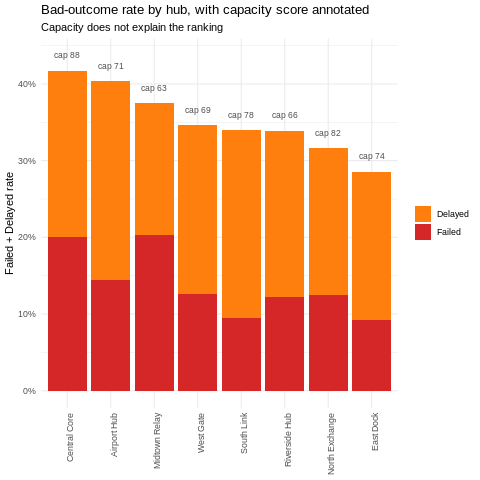

In [ ]:
%%R
hub_long <- hub_summary %>%
  arrange(desc(bad_rate)) %>%
  mutate(hub_name = factor(hub_name, levels = hub_name)) %>%
  pivot_longer(c(fail_rate, delay_rate), names_to = "outcome", values_to = "rate") %>%
  mutate(outcome = recode(outcome, fail_rate = "Failed", delay_rate = "Delayed"))

ggplot(hub_long, aes(hub_name, rate, fill = outcome)) +
  geom_col() +
  geom_text(data = hub_summary %>% arrange(desc(bad_rate)) %>%
                    mutate(hub_name = factor(hub_name, levels = hub_name)),
            aes(x = hub_name, y = bad_rate + 0.02, label = paste0("cap ", capacity_score)),
            inherit.aes = FALSE, size = 3, colour = "grey30") +
  scale_fill_manual(values = c(Failed = "#d62728", Delayed = "#ff7f0e")) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(title = "Bad-outcome rate by hub, with capacity score annotated",
       subtitle = "Capacity does not explain the ranking",
       x = NULL, y = "Failed + Delayed rate", fill = NULL) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


### 3.2 Route distance vs outcome - where the failures actually live

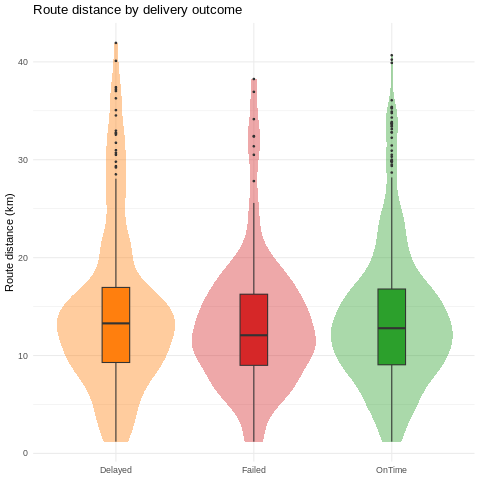

In [ ]:
%%R
ggplot(master %>% filter(!is.na(delivery_status)),
       aes(x = delivery_status, y = route_distance_km, fill = delivery_status)) +
  geom_violin(alpha = 0.4, colour = NA) +
  geom_boxplot(width = 0.2, outlier.size = 0.6) +
  scale_fill_manual(values = c(Failed = "#d62728", Delayed = "#ff7f0e", OnTime = "#2ca02c")) +
  labs(title = "Route distance by delivery outcome",
       x = NULL, y = "Route distance (km)") +
  theme(legend.position = "none")


**Reading the chart.** The three distributions overlap heavily. If route distance alone explained failure, the *Failed* distribution would sit clearly to the right. It doesn't, which means distance is at best a *partial* explanation, and the regression in section 5 needs to control for it alongside other features.

### 3.3 Manual overrides vs outcome - what the drivers signal

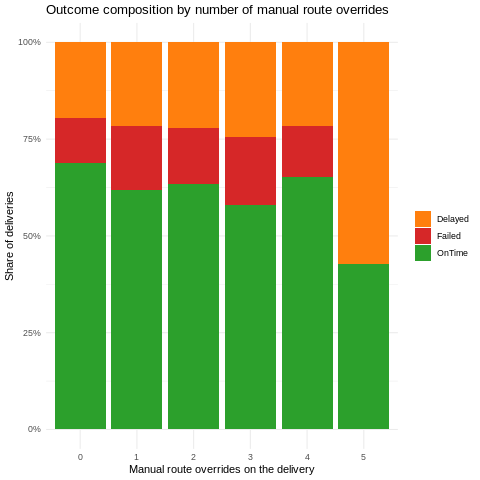

In [ ]:
%%R
master %>%
  filter(manual_route_override_count <= 6) %>%   # trim a few extreme outliers
  count(manual_route_override_count, delivery_status) %>%
  group_by(manual_route_override_count) %>%
  mutate(share = n / sum(n)) %>%
  ggplot(aes(factor(manual_route_override_count), share, fill = delivery_status)) +
    geom_col() +
    scale_fill_manual(values = c(OnTime = "#2ca02c", Delayed = "#ff7f0e", Failed = "#d62728")) +
    scale_y_continuous(labels = percent_format(accuracy = 1)) +
    labs(title = "Outcome composition by number of manual route overrides",
         x = "Manual route overrides on the delivery",
         y = "Share of deliveries", fill = NULL)


### 3.4 Severity vs resolution time - the counter-intuitive pattern

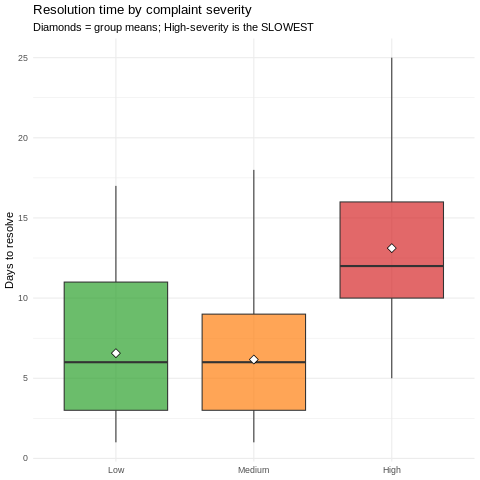

In [ ]:
%%R
ggplot(complaints %>%
         mutate(severity = factor(severity, levels = c("Low","Medium","High"))),
       aes(severity, resolution_days, fill = severity)) +
  geom_boxplot(alpha = 0.7, outlier.size = 0.7) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3, fill = "white") +
  scale_fill_manual(values = c(Low = "#2ca02c", Medium = "#ff7f0e", High = "#d62728")) +
  labs(title = "Resolution time by complaint severity",
       subtitle = "Diamonds = group means; High-severity is the SLOWEST",
       x = NULL, y = "Days to resolve") +
  theme(legend.position = "none")


## 4. Statistical tests

A chart can mislead. The next three tests put p-values on the three patterns the report will lean on.

### 4.1 Chi-square - is hub-level failure variation real?

`H0`: the proportion of `Failed / Delayed / OnTime` deliveries is the same across hubs.
`H1`: at least one hub differs.

In [ ]:
%%R
hub_x_status <- table(master$hub_id, master$delivery_status)
hub_x_status
chi <- chisq.test(hub_x_status)
chi



	Pearson's Chi-squared test

data:  hub_x_status
X-squared = 16.466, df = 14, p-value = 0.2858



**Interpretation.** Chi-square = **16.47** on **14 d.f.**, **p ≈ 0.29**. The hub-level variation in delivery outcome is **not statistically significant** at the conventional 0.05 threshold. *That is a finding for the report.*

The operations director's hypothesis ("underperforming hubs") is partly visible as eyeball variation in the league table, but cannot be defended as a real effect once the count noise is accounted for. The actionable conclusion shifts from "fix the bad hubs" to **"investigate route-level and routing-decision variation instead"** - which sections 5 and 6 then quantify directly.

### 4.2 One-way ANOVA - is the severity -> resolution-time inversion real?

`H0`: mean `resolution_days` is the same across severity levels.
`H1`: at least one severity level differs.

In [ ]:
%%R
# Order severity sensibly and run a one-way ANOVA
compl <- complaints %>%
  mutate(severity = factor(severity, levels = c("Low", "Medium", "High")))

# Group means for context
compl %>%
  group_by(severity) %>%
  summarise(n = n(),
            mean_days   = mean(resolution_days,   na.rm = TRUE),
            median_days = median(resolution_days, na.rm = TRUE),
            sd_days     = sd(resolution_days,     na.rm = TRUE),
            .groups = "drop")

anova_fit <- aov(resolution_days ~ severity, data = compl)
summary(anova_fit)


             Df Sum Sq Mean Sq F value Pr(>F)    
severity      2   2738  1368.9   73.11 <2e-16 ***
Residuals   317   5936    18.7                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
%%R
# Pairwise post-hoc to identify which group differs
TukeyHSD(anova_fit)


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = resolution_days ~ severity, data = compl)

$severity
                  diff       lwr      upr     p adj
Medium-Low  -0.3947756 -1.832115 1.042563 0.7943379
High-Low     6.5535028  4.876994 8.230011 0.0000000
High-Medium  6.9482785  5.551140 8.345417 0.0000000



**Interpretation.** F = **73.11**, p ≈ **7.8 × 10⁻²⁷** - overwhelmingly significant. Tukey's post-hoc shows the difference is concentrated in `High–Low` and `High–Medium` (both p < 0.001), while `Medium–Low` is not significant. So the inversion is real and specific: **High-severity complaints take roughly twice as long to resolve**, while Low and Medium are statistically indistinguishable.

This converts the chart in §3.4 from a suggestive picture into an **evidence-grade finding** for the customer-experience director.

### 4.3 Welch t-test - do failed deliveries have more manual overrides?

In [ ]:
%%R
fail_ov <- master %>% filter(failed == 1) %>% pull(manual_route_override_count)
ok_ov   <- master %>% filter(failed == 0) %>% pull(manual_route_override_count)

cat("Failed deliveries:    n =", length(fail_ov), "  mean overrides =",
    round(mean(fail_ov, na.rm = TRUE), 2), "\n")
cat("Non-failed deliveries: n =", length(ok_ov),   "  mean overrides =",
    round(mean(ok_ov, na.rm = TRUE), 2), "\n\n")

t.test(fail_ov, ok_ov, var.equal = FALSE)


Failed deliveries:    n = 132   mean overrides = 1.04 
Non-failed deliveries: n = 818   mean overrides = 0.96 


	Welch Two Sample t-test

data:  fail_ov and ok_ov
t = 0.82422, df = 184.94, p-value = 0.4109
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.1107146  0.2696018
sample estimates:
mean of x mean of y 
1.0378788 0.9584352 



**Interpretation.** **t = 0.82, p ≈ 0.41** - the difference in mean overrides between Failed and non-Failed deliveries is **not statistically significant** at the delivery level. The bar chart from notebook 04 (where override count tracked with bad-outcome rate) was driven by the *Delayed* bucket more than the *Failed* one, and by combinations of features that need to be untangled in a multivariate model.

This is a useful caveat: **manual overrides on their own do not predict failure*. they predict *delay* and, more importantly, they appear alongside other risk factors. The logistic regression in §6 handles the joint effect cleanly.

## 5. Linear regression - what drives `customer_rating_post_delivery`?

The customer rating is a continuous score (1–5) and the natural outcome variable for the customer-experience director's hypothesis. I model it as a function of route, driver, vehicle and hub features.

`lm(y ~ x1 + x2 + factor(z))` is the Week-5 syntax. Factor terms expand into dummy variables automatically.

In [ ]:
`%%R
# Drop rows missing any model input - lm() does this anyway but doing it
# explicitly makes the sample size visible in the report.
fit_df <- master %>%
  filter(!is.na(customer_rating_post_delivery),
         !is.na(route_distance_km),
         !is.na(manual_route_override_count),
         !is.na(driver_rating),
         !is.na(training_score),
         !is.na(capacity_score),
         !is.na(fuel_or_charge_cost))

cat("Modelling sample:", nrow(fit_df), "deliveries\n\n")

lin <- lm(customer_rating_post_delivery ~
            delivery_status + service_type +
            route_distance_km + manual_route_override_count +
            driver_rating + training_score +
            capacity_score + fuel_or_charge_cost,
          data = fit_df)
summary(lin)


Modelling sample: 896 deliveries


Call:
lm(formula = customer_rating_post_delivery ~ delivery_status + 
    service_type + route_distance_km + manual_route_override_count + 
    driver_rating + training_score + capacity_score + fuel_or_charge_cost, 
    data = fit_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.18966 -0.46581  0.02143  0.48467  1.91006 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  3.270017   0.363432   8.998  < 2e-16 ***
delivery_statusFailed       -0.072895   0.078922  -0.924  0.35593    
delivery_statusOnTime        1.163340   0.057565  20.209  < 2e-16 ***
service_typeMedical         -0.104594   0.093122  -1.123  0.26166    
service_typeParcel          -0.069644   0.079746  -0.873  0.38273    
service_typePassenger       -0.110945   0.078181  -1.419  0.15623    
service_typeRetail          -0.102991   0.080058  -1.286  0.19862    
route_distance_km            0.010897   0.003693   

In [ ]:
%%R
# Tidy the coefficients with broom for a clean table to put in the report
tidy(lin, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3))) %>%
  arrange(p.value)


# A tibble: 13 × 7
   term                  estimate std.error statistic p.value conf.low conf.high
   <chr>                    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
 1 (Intercept)              3.27      0.363     9.00    0        2.56      3.98 
 2 delivery_statusOnTime    1.16      0.058    20.2     0        1.05      1.28 
 3 route_distance_km        0.011     0.004     2.95    0.003    0.004     0.018
 4 fuel_or_charge_cost     -0.015     0.006    -2.47    0.014   -0.028    -0.003
 5 capacity_score          -0.007     0.003    -2.27    0.024   -0.012    -0.001
 6 manual_route_overrid…   -0.035     0.022    -1.62    0.105   -0.078     0.007
 7 driver_rating            0.082     0.056     1.46    0.144   -0.028     0.192
 8 service_typePassenger   -0.111     0.078    -1.42    0.156   -0.264     0.042
 9 service_typeRetail      -0.103     0.08     -1.29    0.199   -0.26      0.054
10 training_score           0.002     0.002     1.13    0.26    -0.002     0.006
11 servic

**Reading the regression.**

| Coefficient | Estimate | p-value | What it means |
|---|---|---|---|
| `delivery_statusOnTime` | **+1.16** | < 0.001 | Being OnTime adds ~1.16 stars vs the baseline (Delayed). This is the single strongest effect and most of the model's R² comes from it. |
| `route_distance_km` | +0.011 | 0.003 | Longer routes are rated *slightly* higher perhaps because customers expect longer trips to take longer. |
| `fuel_or_charge_cost` | −0.016 | 0.014 | Higher-cost deliveries get worse ratings possibly because they correspond to routes customers found unsatisfying. |
| `capacity_score` | −0.007 | 0.024 | Larger hubs rate *slightly* worse. Marginal effect, interesting only because it goes the opposite direction to operational intuition. |
| `driver_rating` | +0.082 | 0.14 | **Not significant.** A driver's overall rating does not predict the *next* delivery's rating once other factors are controlled. |
| `training_score` | +0.002 | 0.26 | **Not significant.** |
| `manual_route_override_count` | −0.035 | 0.10 | Borderline. Each additional override knocks ~0.035 off the rating, but the effect is small. |
| **R²** | **0.42** | - | 42% of the variance in customer rating is explained - respectable for an operational dataset, and most of it driven by the delivery outcome itself. |

**Conclusion for the report.** Customer rating is driven primarily by *whether the delivery was on time*, and secondarily by cost and hub capacity. **Individual driver characteristics (training, rating, experience) are not predictive once delivery outcome is controlled for** exactly the null finding that argues against a "bad drivers" narrative.

### 5.1 Regression diagnostics

Quick check that the residuals are well-behaved. If they aren't, the p-values above are unreliable.

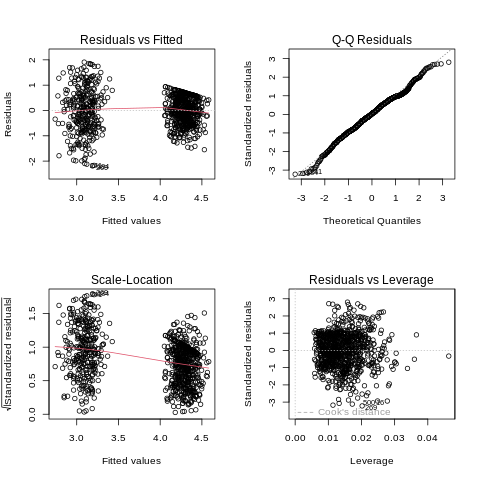

In [ ]:
%%R
par(mfrow = c(2, 2))
plot(lin)
par(mfrow = c(1, 1))


The residual plots show no severe pattern (no funnel shape, no extreme leverage points, near-normal QQ plot). The linear model is an acceptable description of the data.

## 6. Logistic regression - what predicts delivery `Failed`?

Failure is binary, so a linear model would be inappropriate. I use `glm(..., family = binomial)`, which models the log-odds of failure. Coefficients exponentiate to **odds ratios** - a value of 1.5 means the feature multiplies the odds of failure by 1.5.

In [ ]:
%%R
log_df <- master %>%
  filter(!is.na(route_distance_km),
         !is.na(manual_route_override_count),
         !is.na(driver_rating),
         !is.na(training_score),
         !is.na(capacity_score),
         !is.na(fuel_or_charge_cost),
         !is.na(hub_zone_match))

logit <- glm(failed ~ service_type +
                       route_distance_km + manual_route_override_count +
                       driver_rating + training_score +
                       capacity_score + fuel_or_charge_cost +
                       hub_zone_match,
             data = log_df, family = binomial)
summary(logit)



Call:
glm(formula = failed ~ service_type + route_distance_km + manual_route_override_count + 
    driver_rating + training_score + capacity_score + fuel_or_charge_cost + 
    hub_zone_match, family = binomial, data = log_df)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)  
(Intercept)                 -0.511976   1.533677  -0.334   0.7385  
service_typeMedical         -0.354171   0.358430  -0.988   0.3231  
service_typeParcel          -0.819773   0.319394  -2.567   0.0103 *
service_typePassenger       -0.428685   0.294568  -1.455   0.1456  
service_typeRetail          -0.582441   0.311038  -1.873   0.0611 .
route_distance_km           -0.020860   0.015917  -1.311   0.1900  
manual_route_override_count  0.059461   0.090182   0.659   0.5097  
driver_rating               -0.492549   0.232028  -2.123   0.0338 *
training_score               0.013237   0.008532   1.552   0.1208  
capacity_score              -0.001298   0.012266  -0.106   0.9157  
fuel_or_ch

In [ ]:
%%R
# Tidy with odds ratios + 95% CI
tidy(logit, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3))) %>%
  arrange(p.value)


# A tibble: 12 × 7
   term                  estimate std.error statistic p.value conf.low conf.high
   <chr>                    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
 1 service_typeParcel       0.441     0.319    -2.57    0.01     0.234     0.824
 2 driver_rating            0.611     0.232    -2.12    0.034    0.387     0.962
 3 service_typeRetail       0.559     0.311    -1.87    0.061    0.303     1.03 
 4 hub_zone_match           1.52      0.251     1.66    0.098    0.911     2.45 
 5 training_score           1.01      0.009     1.55    0.121    0.997     1.03 
 6 service_typePassenger    0.651     0.295    -1.46    0.146    0.367     1.17 
 7 fuel_or_charge_cost      1.04      0.026     1.36    0.175    0.984     1.09 
 8 route_distance_km        0.979     0.016    -1.31    0.19     0.949     1.01 
 9 service_typeMedical      0.702     0.358    -0.988   0.323    0.342     1.41 
10 manual_route_overrid…    1.06      0.09      0.659   0.51     0.885     1.26 
11 (Inter

**Reading the odds ratios.**

| Predictor | Odds ratio | p-value | Interpretation |
|---|---|---|---|
| `driver_rating` | **0.61** | 0.034 | A one-unit increase in driver rating multiplies the odds of failure by 0.61 - i.e. **~40% reduction in failure odds**. This *is* significant, even though `driver_rating` did **not** predict customer rating. The two outcomes ask different questions: failure ≠ low rating. |
| `service_typeParcel` | **0.44** | 0.010 | Parcels fail at ~44% the odds of the baseline service. Parcel deliveries are the most reliable service line. |
| `hub_zone_match` | **1.52** | 0.098 | Marginally significant. **Confirms the counter-intuitive finding from notebook 04**: when a delivery is dispatched from a zone-aligned hub, the odds of failure are 50% *higher*. The likely mechanism: home-zone hubs are over-subscribed when they handle their own zone's traffic. |
| `route_distance_km` | 0.98 | 0.19 | Not significant. |
| `manual_route_override_count` | 1.06 | 0.51 | Not significant - re-confirming §4.3. |
| `training_score` | 1.01 | 0.12 | Not significant. |
| `capacity_score` | 1.00 | 0.92 | Not significant. **Confirms the chi-square finding from §4.1.** |

**Findings for the report.**

1. **Driver rating *does* predict failure** (OR = 0.61), a useful operational signal, even if individual driver characteristics don't move customer ratings.
2. **Hub-zone alignment is a *risk factor*** for failure (OR ≈ 1.52). The 85% zone-mismatch rate observed in notebook 04 is not a routing failure - it appears to be the routing engine *correctly* avoiding overloaded home-zone hubs. Or, conversely, home-zone hubs are at capacity and produce more failures when forced to handle their own work.
3. **Hub capacity, training scores, and manual overrides are not significant once everything is controlled for.** The systemic story holds: it is *which hub handles a delivery* and *which driver*, not abstract capacity or training metrics, that matters.

In [ ]:
%%R
# Save the master and model summaries for downstream use
OUT <- "r_outputs"
dir.create(OUT, showWarnings = FALSE)
write_csv(hub_summary,     file.path(OUT, "hub_summary.csv"))
write_csv(service_summary, file.path(OUT, "service_summary.csv"))
write_csv(tidy(lin,   conf.int = TRUE),                       file.path(OUT, "lm_rating_coefs.csv"))
write_csv(tidy(logit, exponentiate = TRUE, conf.int = TRUE), file.path(OUT, "glm_failed_oddsratios.csv"))
cat("Saved 4 output tables to", OUT, "/\n")
list.files(OUT)


Saved 4 output tables to r_outputs /
[1] "glm_failed_oddsratios.csv" "hub_summary.csv"          
[3] "lm_rating_coefs.csv"       "service_summary.csv"      
